In [3]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import statsmodels.api as sma

### Oefening 88
Gasmaatschappijen moeten voldoende gastoevoer voorzien om hun klanten het ganse jaar door te bevoorraden. Bij de planning wil men in staat zijn de benodigde hoeveelheid te voorspellen op basis van gegevens rond temperatuur van de dag zelf, van de voorbije dag, de windsnelheid, het feit of het weekend is of niet.  

a) Stel op basis van de data die voorhanden is, een lineair regressiemodel op dat ons in staat moet stellen om de nodige gashoeveelheid te modelleren.

b) Hoeveel procent van de variantie kan verklaard worden door het regressiemodel ? Interpreteer.

c) Wat is volgens het model de hoeveelheid gas die de maatschappij moet voorzien als de temperatuur van de dag (woensdag) gelijk is aan 18 graden Celcius, de temperatuur van de dag ervoor 15 graden Celcius, de windsnelheid 10 bedraagt?

d) Wat is volgens het model het 95% betrouwbaarheidsinterval voor de coëfficiënt bij de temperatuur van de dag?  

Data : gasbedrijf.csv

In [2]:
data = pd.read_csv("bestanden/gasbedrijf.csv")
yG=data.gastoevoer
xT=data.temperatuur
xTVD=data.temp_vorige_dag
xWS=data.windsnelheid
xW=data.weekend

In [4]:
xT_TVD_WS_W=np.column_stack((xT,xTVD,xWS,xW))
X=sma.add_constant(xT_TVD_WS_W)
modelM=sma.OLS(yG,X).fit()
print(modelM.summary())

                            OLS Regression Results                            
Dep. Variable:             gastoevoer   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     97.37
Date:                Sat, 16 May 2026   Prob (F-statistic):           6.27e-05
Time:                        10:27:36   Log-Likelihood:                -34.074
No. Observations:                  10   AIC:                             78.15
Df Residuals:                       5   BIC:                             79.66
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.3905     17.113     22.929      0.0

In [5]:
XE=sma.add_constant(xT)
modelE=sma.OLS(yG,XE).fit()
print(modelE.summary())

                            OLS Regression Results                            
Dep. Variable:             gastoevoer   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     299.5
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.27e-07
Time:                        10:29:48   Log-Likelihood:                -37.669
No. Observations:                  10   AIC:                             79.34
Df Residuals:                       8   BIC:                             79.94
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         399.4760      7.524     53.095      

In [7]:
residuen=modelE.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1885 als teststatistiek, met bijhorende p-waarde 0.8067.


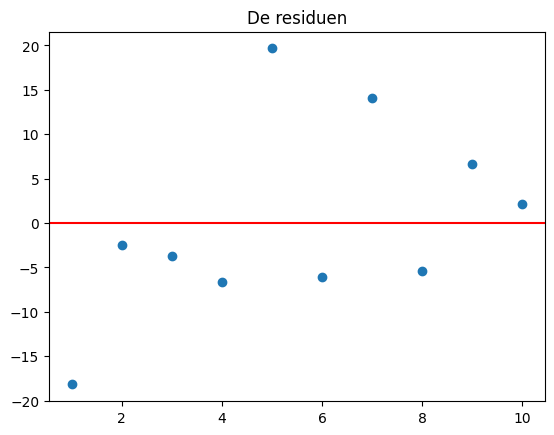

In [8]:
aantal=len(residuen)
plt.scatter(np.linspace(1,aantal,aantal),residuen)
plt.title("De residuen")
plt.axhline(y=0, color='red')

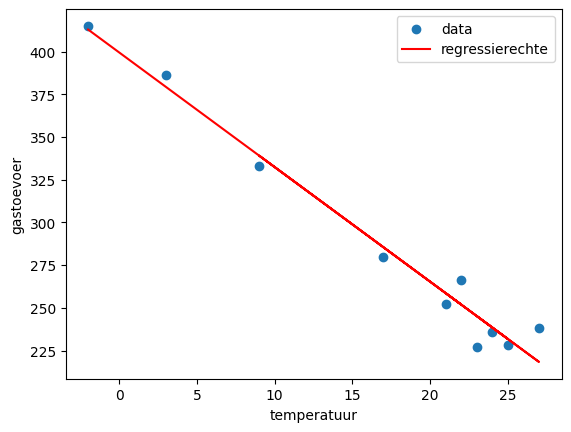

In [9]:
plt.scatter(xT,yG,label='data')
plt.plot(xT,modelE.fittedvalues,color='red',label='regressierechte')
plt.xlabel('temperatuur')
plt.ylabel('gastoevoer')
plt.legend()

In [10]:
print("hoeveelheid gas = -6.7086 * 18 + 399.4760 = ",-6.7086*18+399.4760)

hoeveelheid gas = -6.7086 * 18 + 399.4760 =  278.7212


### Oefening 89
Twee wijnproevers werd gevraagd een rangschikking te maken van 9 gegeven wijnen.  

a) Bereken de correlatiecoëfficiënt van de scores van beide wijnproevers en trek er je conclusies uit over de mening van de twee kenners.

b) Maak een gepaste grafiek die het verband tussen de 2 beoordelingen weergeeft.  

Data : wijndegustatie.csv

In [11]:
data = pd.read_csv("bestanden/wijndegustatie.csv")

corcoef,pwaarde = spstat.pearsonr(data.wijnkenner_1,data.wijnkenner_2)
print(f"De correlatiecoëfficiënt is {corcoef} met p-waarde = {pwaarde}")

De correlatiecoëfficiënt is 0.13333333333333336 met p-waarde = 0.7323675052362977


Text(0, 0.5, 'wijnkenner 2')

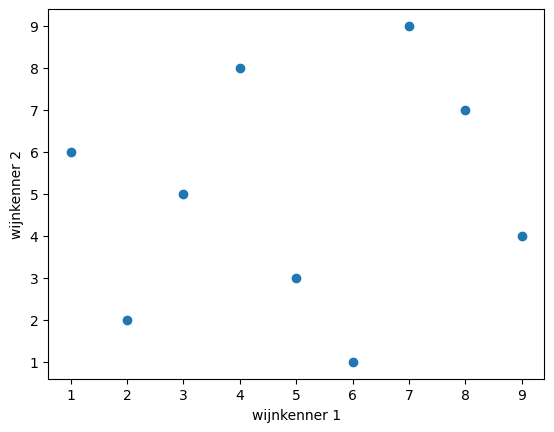

In [13]:
plt.scatter(data.wijnkenner_1,data.wijnkenner_2)
plt.xlabel('wijnkenner 1')
plt.ylabel('wijnkenner 2')

### Oefening 90
Het gewicht van personen wordt vergeleken met de systolische bloeddruk. Dit geeft:

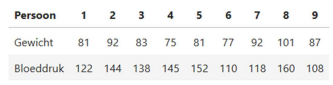

Bepaal het lineair verband dat algemeen de bloeddruk uitdrukt in termen van het gewicht. Bespreek voor $\alpha = 0.05$.

In [14]:
xG=[81,92,83,75,81,77,92,101,87]
yB=[122,144,138,145,152,110,118,160,108]

X=sma.add_constant(xG)
model=sma.OLS(yB,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                 -0.042
Method:                 Least Squares   F-statistic:                    0.6776
Date:                Sat, 16 May 2026   Prob (F-statistic):              0.438
Time:                        10:40:36   Log-Likelihood:                -38.312
No. Observations:                   9   AIC:                             80.62
Df Residuals:                       7   BIC:                             81.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.2405     70.465      1.068      0.3

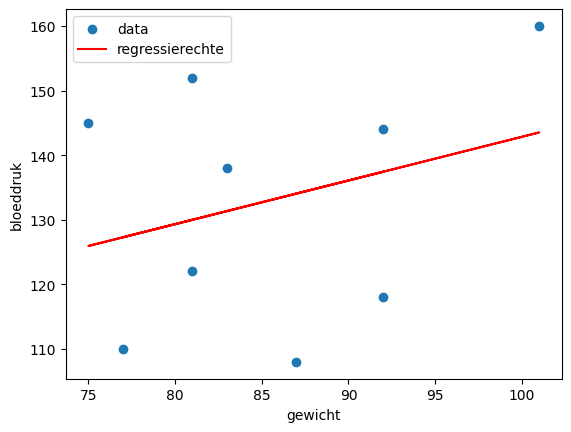

In [15]:
plt.scatter(xG,yB,label='data')
plt.plot(xG,model.fittedvalues,color='red',label='regressierechte')
plt.xlabel('gewicht')
plt.ylabel('bloeddruk')
plt.legend()

### Oefening 91
Gegeven zijn volgende meetresultaten:

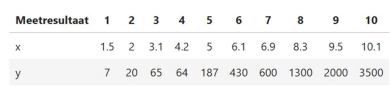

Bepaal op basis van deze gegevens het best passende lineair verband $y = \beta_0 + \beta_1 x$. Kan je het model verbeteren?

In [16]:
x=np.array([1.5,2,3.1,4.2,5,6.1,6.9,8.3,9.5,10.1])
y=np.array([7,20,65,64,187,430,600,1300,2000,3500])

X=sma.add_constant(x)
model=sma.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     23.06
Date:                Sat, 16 May 2026   Prob (F-statistic):            0.00135
Time:                        10:43:28   Log-Likelihood:                -77.333
No. Observations:                  10   AIC:                             158.7
Df Residuals:                       8   BIC:                             159.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1028.8026    431.226     -2.386      0.0

In [17]:
residuen=model.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1814 als teststatistiek, met bijhorende p-waarde 0.8407.


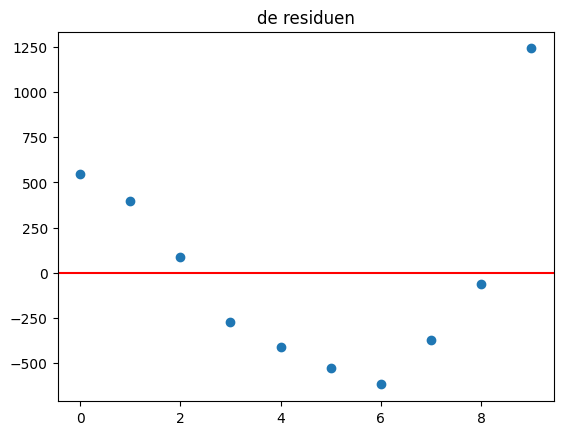

In [18]:
plt.scatter(np.linspace(0,9,10),residuen)
plt.title('de residuen')
plt.axhline(y=0, color='red')
plt.show()

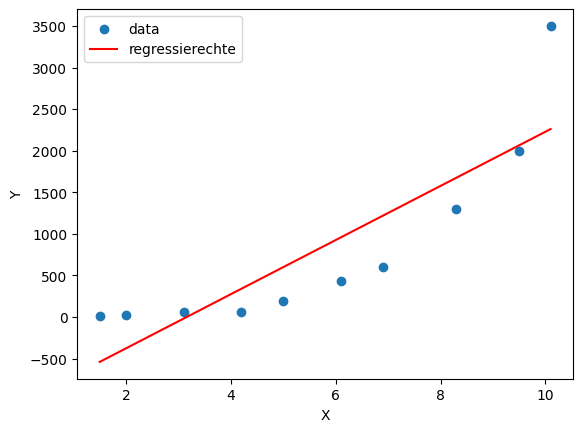

In [19]:
plt.scatter(x,y,label='data')
plt.plot(x,model.fittedvalues,color='red',label='regressierechte')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [20]:
XenXkwadraat=np.column_stack((x,x**2))
Xpar=sma.add_constant(XenXkwadraat)
modelK=sma.OLS(y,Xpar).fit()
print(modelK.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     62.66
Date:                Sat, 16 May 2026   Prob (F-statistic):           3.40e-05
Time:                        10:47:20   Log-Likelihood:                -69.418
No. Observations:                  10   AIC:                             144.8
Df Residuals:                       7   BIC:                             145.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        751.3757    400.804      1.875      0.1

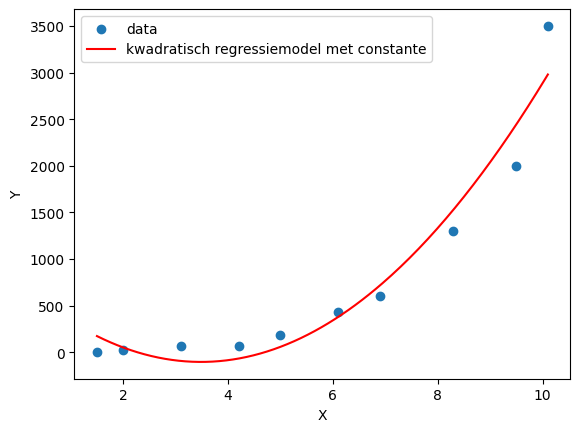

In [21]:
plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
XenXkwadraatrange=np.column_stack((xrange,xrange**2))
Xverwacht=sma.add_constant(XenXkwadraatrange)
YverwachtK=modelK.predict(Xverwacht)
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [22]:
modelKzc=sma.OLS(y,XenXkwadraat).fit()
print(modelKzc.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.949
Model:                            OLS   Adj. R-squared (uncentered):              0.936
Method:                 Least Squares   F-statistic:                              74.72
Date:                Sat, 16 May 2026   Prob (F-statistic):                    6.67e-06
Time:                        10:50:02   Log-Likelihood:                         -71.452
No. Observations:                  10   AIC:                                      146.9
Df Residuals:                       8   BIC:                                      147.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

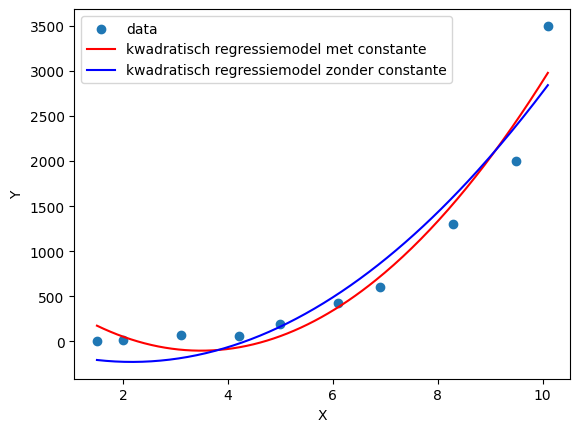

In [23]:
plt.scatter(x,y,label='data')
YverwachtKzc=modelKzc.predict(XenXkwadraatrange)
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.plot(xrange,YverwachtKzc,color='blue',label='kwadratisch regressiemodel zonder constante')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [24]:
lny=np.log(y)
Xln=sma.add_constant(x)
modelLN=sma.OLS(lny,Xln).fit()
print(modelLN.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     249.9
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.57e-07
Time:                        10:54:43   Log-Likelihood:                -3.4750
No. Observations:                  10   AIC:                             10.95
Df Residuals:                       8   BIC:                             11.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6222      0.267      6.067      0.0

In [25]:
beta0=np.e**1.6222
print("e^1.6222 = ", beta0)

e^1.6222 =  5.064219352711359


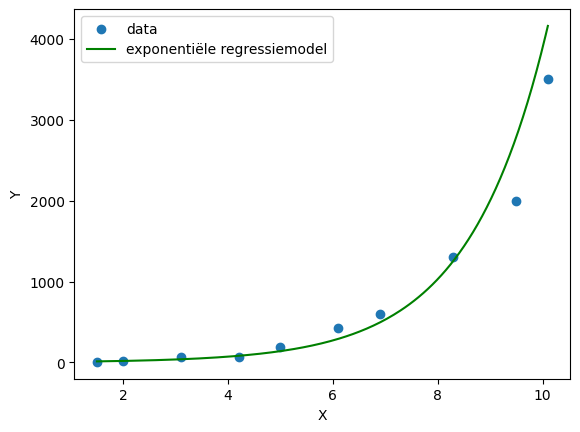

In [27]:
plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
Xverwacht=sma.add_constant(xrange)
ln_verwacht=modelLN.predict(Xverwacht)
yverwacht=np.exp(ln_verwacht)
plt.plot(xrange,yverwacht,color='green',label='exponentiële regressiemodel')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

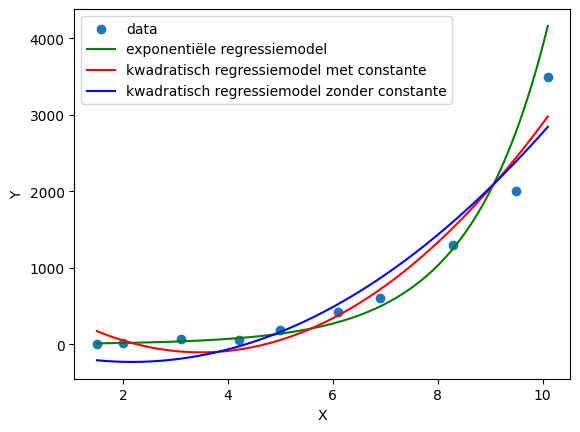

In [28]:
plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
Xverwacht=sma.add_constant(xrange)
ln_verwacht=modelLN.predict(Xverwacht)
yverwacht=np.exp(ln_verwacht)
plt.plot(xrange,yverwacht,color='green',label='exponentiële regressiemodel')
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.plot(xrange,YverwachtKzc,color='blue',label='kwadratisch regressiemodel zonder constante')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

### Oefening 93  
Men wil bestuderen hoe de weerstand van rubber tegen afschuren beïnvloed wordt door de hardheid ($x_1$) en treksterkte ($x_2$) van rubber. Twintig monsters rubber zijn getest op de hardheid (hoe hoger het getal des te sterker is het rubber) en treksterkte (in kg/cm²). Daarna is elk monster een uurlang afgeschuurd (elk monster op dezelfde manier) en is het afgeschuurde gewicht (in gram) aan rubber per uur (y) bepaald. Bepaal het meervoudige lineaire model $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2$ en illustreer met een 3D tekening.

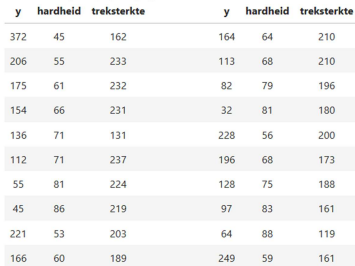

In [29]:
y=np.array([372, 206, 175, 154, 136, 112, 55, 45, 221, 166, 164, 113, 82, 32, 228, 196, 128, 97, 64, 249])
H=np.array([45, 55, 61, 66, 71, 71, 81, 86, 53, 60, 64, 68, 79, 81, 56, 68, 75, 83, 88, 59])
T=np.array([162, 233, 232, 231, 131, 237, 224, 219, 203, 189, 210, 210, 196, 180, 200, 173, 188, 161, 119, 161])

In [30]:
HenT=np.column_stack((H,T))
X=sma.add_constant(HenT)
modelM=sma.OLS(y,X).fit()
print(modelM.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     83.99
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.54e-09
Time:                        11:04:18   Log-Likelihood:                -92.215
No. Observations:                  20   AIC:                             190.4
Df Residuals:                      17   BIC:                             193.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        721.7233     54.404     13.266      0.0

In [31]:
residuen=modelM.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1194 als teststatistiek, met bijhorende p-waarde 0.9060.


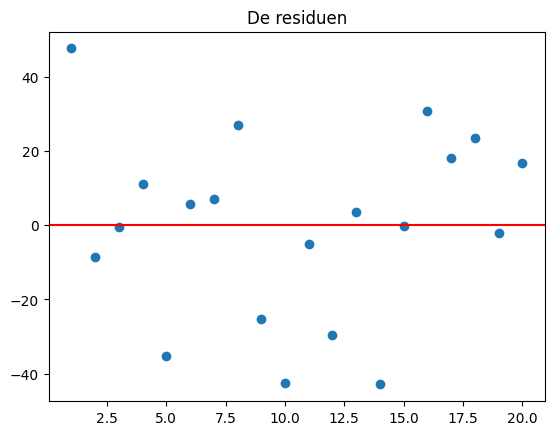

In [32]:
aantal=len(residuen)
plt.scatter(np.linspace(1,aantal,aantal),residuen)
plt.title("De residuen")
plt.axhline(y=0, color='red')

Text(0.5, 0.92, 'afgeschuurde gewicht (in gram) aan rubber per uur')

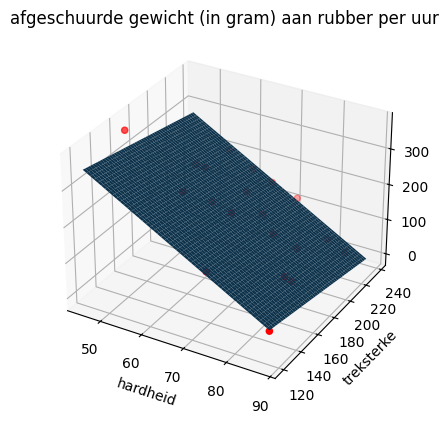

In [33]:
fig=plt.figure()
ax=plt.axes(projection='3d')

ax.scatter(H,T,y,color='red',marker='o')

bereikH=np.linspace(min(H),max(H),200)
bereikT=np.linspace(min(T),max(T),200)
[XH,YT] = np.meshgrid(bereikH,bereikT)
X=np.column_stack((XH.ravel(),YT.ravel()))
Xverwacht=sma.add_constant(X)
Zy=modelM.predict(Xverwacht).reshape(XH.shape)
ax.plot_surface(XH,YT,Zy)
ax.set_xlabel("hardheid")
ax.set_ylabel("treksterke")
ax.set_title("afgeschuurde gewicht (in gram) aan rubber per uur")